# 1. Load the Packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from datetime import datetime, date, timedelta
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# Shows plots in jupyter notebook
%matplotlib inline


# 2. Load the dataset (set the directory)

In [2]:
# Set the working directory to the location of the data file
import os 
os.chdir('/Users/surajgurung/Library/CloudStorage/OneDrive-UniversityofFlorida/AI&FINtech/JPMorgan_Simulation')

# Load the data set
df = pd.read_csv('Loan_Data.csv')

df.columns
df.dtypes
df.head(5)



,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


# 3. Define the input 
- These are the X- variables

In [3]:
features = ['credit_lines_outstanding', 'debt_to_income', 'payment_to_income', 'years_employed', 'fico_score']

# 4. Create payment-to-income ratio

In [4]:
df['payment_to_income'] = df['loan_amt_outstanding']/df['income']
df.head(5)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,payment_to_income
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,0.066909
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,0.073510
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,0.051058
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0.064105
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0.057395


# 5. Create debt-to-income ratio

In [5]:
df['debt_to_income'] = df['total_debt_outstanding'] / df['income']

# 6. Fit the logistic regression model

In [6]:
clf = LogisticRegression(random_state=0, solver='liblinear', tol=1e-5, max_iter=10000).fit(df[features], df['default'])
# Print coefficients and intercept
print(clf.coef_, clf.intercept_)


[[ 8.18520373  0.54490854  0.01994244 -2.77630853 -0.02418391]] [-0.09162643]


# 7. Predict default class

In [7]:
y_pred = clf.predict(df[features])
y_pred

array([0, 1, 0, ..., 0, 0, 0])

# 8. Compute the ROC curve

In [8]:
y_prob = clf.predict_proba(df[features])[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(df['default'], y_prob)

# Print misclassification rate
print((1.0*(abs(df['default']-y_pred)).sum()) / len(df)) # 3.7% misclassification rate

0.0037


# 9. Print AUC and Plot ROC Curve

AUC (ROC area): 0.9999183229635983


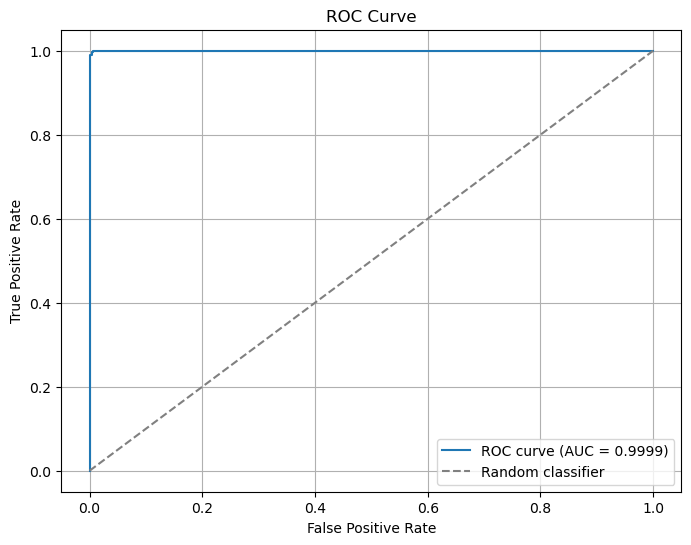

In [9]:
auc_score = metrics.auc(fpr, tpr)
print("AUC (ROC area):", auc_score)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 10. Confusion Matrix and Classification Report

Confusion Matrix:
[[8137   12]
 [  25 1826]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9969    0.9985    0.9977      8149
           1     0.9935    0.9865    0.9900      1851

    accuracy                         0.9963     10000
   macro avg     0.9952    0.9925    0.9939     10000
weighted avg     0.9963    0.9963    0.9963     10000



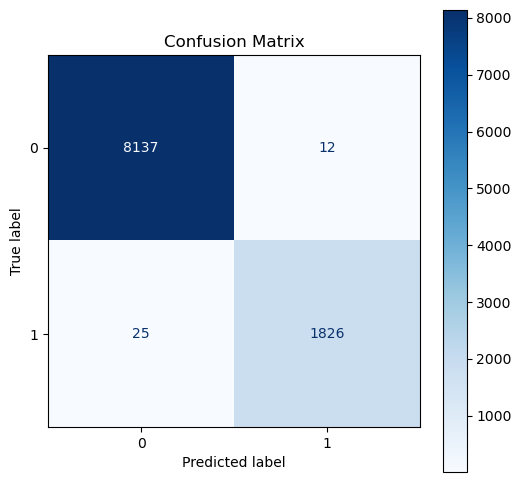

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(df['default'], y_pred)
print('Confusion Matrix:')
print(cm)

print('\nClassification Report:')
print(classification_report(df['default'], y_pred, digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# 11. Maximum Likelihood Estimation
- The code takes borrower FICO scores and defaults, counts how defaults vary by score, and then uses dynamic programming to find the set of bucket boundaries that maximizes the total log-likelihood of observed defaults across a fixed number of FICO buckets.

In [11]:
x = df['default'].to_list()
y = df['fico_score'].to_list()
n = len(x)
print (len(x), len(y))
df.head(5)


10000 10000


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,payment_to_income,debt_to_income
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,0.066909,0.050173
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,0.073510,0.308789
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,0.051058,0.030787
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0.064105,0.033645
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0.057395,0.075435


In [12]:
# Create arrays to count defaults and totals by FICO score
default = [0 for i in range(851)]
total = [0 for i in range(851)]

# Count defaults and total borrowers at each FICO score
for i in range(n):
    y[i] = int(y[i])
    default[y[i]-300] += x[i]
    total[y[i]-300] += 1

# Convert counts into cumulative counts
for i in range(0, 551):
    default[i] += default[i-1]
    total[i] += total[i-1]

In [13]:
# Define the bucket log-likelihood
# Use dynamic programming 

def log_likelihood(n, k):
    p = k/n
    if (p==0 or p==1):
        return 0
    return k*np.log(p)+ (n-k)*np.log(1-p)

r = 10 # no, of buckets
dp = [[[-10**18, 0] for i in range(551)] for j in range(r+1)]

for i in range(r+1):
    for j in range(551):
        if (i==0):
            dp[i][j][0] = 0
        else:
            for k in range(j):
                if (total[j]==total[k]):
                    continue
                if (i==1):
                    dp[i][j][0] = log_likelihood(total[j], default[j])
                else:
                    if (dp[i][j][0] < (dp[i-1][k][0] + log_likelihood(total[j]-total[k], default[j] - default[k]))):
                        dp[i][j][0] = log_likelihood(total[j]-total[k], default[j]-default[k]) + dp[i-1][k][0]
                        dp[i][j][1] = k
                                                     
print (round(dp[r][550][0], 4))
                                                     
k = 550
l = []
while r >= 0:
    l.append(k+300)
    k = dp[r][k][1]
    r -= 1

print(l)


-4217.8245
[850, 753, 752, 732, 696, 649, 611, 580, 552, 520, 300]


## The value: -4217.8245 is the maximum total log-likelihood achievable with 10 buckets over the full FICO range 300–850.

## The bucket boundaries: 300, 520, 552, 580, 611, 649, 696, 732, 752, 753, 850